In [ ]:
from pathlib import Path
import sys

BASE_DIR = Path.cwd()
while BASE_DIR != BASE_DIR.parent and not (BASE_DIR / 'src').exists():
    BASE_DIR = BASE_DIR.parent
SRC_DIR = BASE_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from config import OUTPUT_DIR, DATA_DIR

COHORT = 'SNUH'


In [46]:
import pandas as pd 
import numpy as np
from scipy.stats import chi2_contingency
from itertools import combinations, permutations

import matplotlib.pyplot as plt
import matplotlib 
from scipy.stats import fisher_exact
# import statsmodels.stats.multitest as smt
import seaborn as sns
# from statannotations.Annotator import Annotator
from sklearn.preprocessing import StandardScaler


import os 
from scipy import stats

In [2]:
reduce = ['Raw','PCA2','PCA3','t_SNE','UMAP']
def max_s(data):
    return data[data['silhouette_scores'] == max(data['silhouette_scores'])]

In [3]:
clustering_result = []
for i in reduce:
    print(i)
    ward = pd.read_csv(str(OUTPUT_DIR / 'Clustering' / COHORT / str(i) / 'Hclust' / 'ward_silhouette_scores.csv'))
    average = pd.read_csv(str(OUTPUT_DIR / 'Clustering' / COHORT / str(i) / 'Hclust' / 'average_silhouette_scores.csv'))
    complete = pd.read_csv(str(OUTPUT_DIR / 'Clustering' / COHORT / str(i) / 'Hclust' / 'complete_silhouette_scores.csv'))
    kmeans = pd.read_csv(str(OUTPUT_DIR / 'Clustering' / COHORT / str(i) / 'Kmeans' / 'K_silhouette_scores.csv'))
    d1 = pd.concat([max_s(ward),max_s(average),max_s(complete),max_s(kmeans)]).reset_index(drop=True)
    d1['name'] = ['ward','average','complete','kmeans']
    d1['data'] = i
    clustering_result.append(d1)
    print(d1[['name','K','silhouette_scores']])

Raw
       name  K  silhouette_scores
0      ward  3           0.307313
1   average  3           0.511350
2  complete  3           0.493965
3    kmeans  3           0.469733
PCA2
       name  K  silhouette_scores
0      ward  3           0.444805
1   average  3           0.558238
2  complete  3           0.268240
3    kmeans  3           0.516071
PCA3
       name  K  silhouette_scores
0      ward  3           0.477115
1   average  3           0.506843
2  complete  3           0.508937
3    kmeans  3           0.487894
t_SNE
       name  K  silhouette_scores
0      ward  3           0.354396
1   average  4           0.362472
2  complete  4           0.372782
3    kmeans  3           0.409254
UMAP
       name  K  silhouette_scores
0      ward  4           0.412873
1   average  4           0.379405
2  complete  5           0.367680
3    kmeans  4           0.439055


In [4]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 예시 데이터
df = pd.concat(clustering_result)
# 정규화
scaler = MinMaxScaler()
df['silhouette_norm'] = scaler.fit_transform(df[['silhouette_scores']])
df['ssd_norm'] = scaler.fit_transform(np.log10(df[['ssd_scores']]))
df['ssd_norm'] = 1 - df['ssd_norm']  # SSD는 작을수록 좋음 → 반전

# 최종 종합 점수 (동일 가중치)
df['final_score'] = (df['silhouette_norm'] + df['ssd_norm']) / 2

df[['data', 'name', 'silhouette_scores', 'ssd_scores', 'final_score']].sort_values(by = 'final_score')

,data,name,silhouette_scores,ssd_scores,final_score
0,t_SNE,ward,0.354396,1.505761e+08,0.148544
2,PCA2,complete,0.268240,2.148785e+06,0.180439
1,t_SNE,average,0.362472,9.691931e+07,0.181178
2,t_SNE,complete,0.372782,8.897672e+07,0.202584
0,Raw,ward,0.307313,3.344731e+06,0.229018
1,UMAP,average,0.379405,8.546344e+06,0.313483
2,UMAP,complete,0.367680,4.798016e+06,0.317780
0,UMAP,ward,0.412873,6.094596e+06,0.385543
3,t_SNE,kmeans,0.409254,3.859467e+06,0.398702
0,PCA2,ward,0.444805,2.844591e+06,0.472951


In [5]:
df[['K','data', 'name', 'silhouette_scores', 'ssd_scores', 'final_score']]

,K,data,name,silhouette_scores,ssd_scores,final_score
0,3,Raw,ward,0.307313,3.344731e+06,0.229018
1,3,Raw,average,0.511350,1.160355e+07,0.527991
2,3,Raw,complete,0.493965,4.843745e+06,0.535112
3,3,Raw,kmeans,0.469733,1.658840e+03,0.832138
0,3,PCA2,ward,0.444805,2.844591e+06,0.472951
1,3,PCA2,average,0.558238,3.999366e+06,0.654061
2,3,PCA2,complete,0.268240,2.148785e+06,0.180439
3,3,PCA2,kmeans,0.516071,1.157906e+03,0.927297
0,3,PCA3,ward,0.477115,3.527012e+06,0.519529
1,3,PCA3,average,0.506843,4.272922e+06,0.562639


In [6]:
data = pd.read_csv(str(OUTPUT_DIR / "Clustering" / COHORT / 'PCA2' / 'Kmeans' / 'K_cluster_3_raw_data.csv'"))

data['cluster'].value_counts()

cluster
0    3260
1     723
2     580
Name: count, dtype: int64

In [7]:
def chi_squre(data,feature1, feature2):
    ctab = pd.crosstab(data[feature1],data[feature2])
    stat, p, dof, expected = chi2_contingency(ctab)
    return stat, p,expected

In [8]:
def cate_value_count(data, cate_feature_lst):
    result = pd.DataFrame()
    for feature in cate_feature_lst:
        cate_tmp = pd.DataFrame(data[feature].value_counts())
        cate_tmp.columns =['freq']
        cate_tmp['feature']=feature
        cate_tmp = cate_tmp.reset_index(drop=False)
        cate_tmp.columns = ['index','freq','feature']
        result = pd.concat([result, cate_tmp],axis=0)
    return result

In [9]:
def eGFR_cal(Cr,age, sex):
    if sex == 2 :# 여성
        K = 0.7
        alpha = -0.241 
        last = 1.012
    else:# 남성
        K = 0.9
        alpha = -0.302 
        last = 1
    
    eGFR = 142*((min(Cr/K,1))**alpha)*((max(Cr/K,1))**(-1.2))*((0.9938)**age)*last
    return np.round(eGFR,0)

In [10]:
def mk_eGFR_data(clinical_only_raw):
    eGFR_data = []
    for sample in range(len(clinical_only_raw)):
        eGFR_data.append(eGFR_cal(clinical_only_raw.loc[sample,"Cr"], clinical_only_raw.loc[sample,"age"], clinical_only_raw.loc[sample,"sex"]))
    return eGFR_data

In [11]:
def mkMBP(cli):
    cli['MBP'] = (2*cli['dia'] + cli['sys'])/3
    return cli

In [12]:
raw_data0319 = pd.read_csv('/nfs-data-124/skhan/bds3/시각화모듈/KoGES/Koges_Ansan_Ansung_Urban_Country_SNUH_Gangnam_HTN,LIPID 변경.csv')
raw_data0319['eGFR'] = mk_eGFR_data(raw_data0319)
raw_data0319 = mkMBP(raw_data0319)
raw_data0319.rename(columns = {'sample' : 'dist_id'}, inplace = True)

In [13]:
# # insulin 안산안성데이터 
# insulin_data = pd.read_csv('/nfs-data-123/skhan/SW1/Koges안산안성_insulin_20250226.csv')
# insulin_data.rename(columns = {'sample' : 'dist_id'}, inplace = True)
# insulin_data = insulin_data[['dist_id','FINS','HOMA-IR','HOMA-B']]
# # raw data와 insulin 안산안성데이터 Merge 
# raw_data0319 = pd.merge(raw_data0319, insulin_data).reset_index(drop=True)

In [14]:
# cohort = ['AN','AS','CT','NC']
# cohort = ['NC']
# cohort = ['AN','AS']
cohort = ['55']
raw_data = pd.DataFrame()
for cohort_name in cohort:
    cohort_data = raw_data0319[raw_data0319['area'] == cohort_name].reset_index()
    raw_data = pd.concat([raw_data, cohort_data]).reset_index(drop=True)

In [15]:
data = pd.read_csv(str(OUTPUT_DIR / "Clustering" / COHORT / 'PCA2' / 'Kmeans' / 'K_cluster_3_raw_data.csv'"))
# data = pd.read_csv(str(OUTPUT_DIR / "Clustering" / COHORT / 'PCA3' / 'Hclust'/average_cluster_3_raw_data.csv"))

try:
    print(len(data['sample']))
except:
    shap = pd.read_csv('../../SHAP_total_SNUH_sample.csv')
    sample = shap['sample']
    data['sample'] = sample.values

data.rename(columns = {'sample' : 'dist_id'}, inplace = True)
print(data['cluster'].value_counts())
if data['cluster'].value_counts()[1]>data['cluster'].value_counts()[0]:
    data=data.replace({'cluster':{1:3,0:1}})
    data=data.replace({'cluster':{3:0}})
# data=data.replace({'cluster':{1:3,2:1}})
# data=data.replace({'cluster':{3:2}})

data['cluster'].value_counts()

cluster
0    3260
1     723
2     580
Name: count, dtype: int64


cluster
0    3260
1     723
2     580
Name: count, dtype: int64

In [16]:
data['cluster'].value_counts()

cluster
0    3260
1     723
2     580
Name: count, dtype: int64

In [17]:
# shap_data = pd.read_csv('./shap_with_sample.csv')
# shap_data.columns
# shap_data[np.logical_or(shap_data['area'] == 'AN',shap_data['area'] == 'AS')].reset_index(drop=True).to_csv('./cohort_clustering/ANAS_SHAP.csv',index=False)
# shap_data[shap_data['area'] == 'CT'].reset_index(drop=True).to_csv('./cohort_clustering/CT_SHAP.csv',index=False)
# shap_data[shap_data['area'] == 'NC'].reset_index(drop=True).to_csv('./cohort_clustering/NC_SHAP.csv',index=False)

In [18]:
# raw data + cluster
data = pd.merge(data[['dist_id','cluster']],raw_data).reset_index(drop=True)
data['progress_DM'].value_counts()

progress_DM
0    4147
1     416
Name: count, dtype: int64

In [19]:
data[data['cluster'] == 0]['progress_DM'].value_counts()

progress_DM
0    3194
1      66
Name: count, dtype: int64

In [20]:
data[data['cluster'] == 1]['progress_DM'].value_counts()

progress_DM
0    471
1    252
Name: count, dtype: int64

In [21]:
data[data['cluster'] == 2]['progress_DM'].value_counts()

progress_DM
0    482
1     98
Name: count, dtype: int64

In [22]:
for cluster_name in data['cluster'].sort_values().unique():
    incident_cases = data[data['cluster'] == cluster_name]['progress_DM'].sum()
    
    # 총 person-years
    total_person_years = data[data['cluster'] == cluster_name]['fu_yrs'].sum()
    
    # incident rate 계산
    incident_rate = (incident_cases / total_person_years) * 1000
    
    print(f"cluster{cluster_name+1}: Incident Rate: {incident_rate:.2f} cases per 1,000 person-years")

cluster1: Incident Rate: 5.02 cases per 1,000 person-years
cluster2: Incident Rate: 92.78 cases per 1,000 person-years
cluster3: Incident Rate: 41.95 cases per 1,000 person-years


In [23]:
incident_cases = data['progress_DM'].sum()

# 총 person-years
total_person_years = data['fu_yrs'].sum()

# incident rate 계산
incident_rate = (incident_cases / total_person_years) * 1000

print(f"cluster{cluster_name+1}: Incident Rate: {incident_rate:.2f} cases per 1,000 person-years")

cluster3: Incident Rate: 22.85 cases per 1,000 person-years


In [24]:
# Eluster별 데이터 
C1 = data[data['cluster']==0].reset_index(drop=True)
C2 = data[data['cluster']==1].reset_index(drop=True)
C3 = data[data['cluster']==2].reset_index(drop=True)
# C4 = data[data['cluster']==3].reset_index(drop=True)
data_lst = [C1, C2, C3]
# data_lst = [C1, C2, C3, C4]

In [25]:
P_cluster_lst = ['C1', 'C2', 'C3']#,'C4']

P_combi = list(combinations(P_cluster_lst, 2))
P_combi

[('C1', 'C2'), ('C1', 'C3'), ('C2', 'C3')]

In [26]:
C1['Endotype'] = 'C1'
C2['Endotype'] = 'C2'
C3['Endotype'] = 'C3'
# C4['Endotype'] = 'C4'

In [27]:
pd.options.display.max_rows = 10
total_data = pd.concat(data_lst,axis=0)
total_data = total_data.drop(columns = 'cluster').reset_index(drop=True)
total_data=total_data.replace({'sex':{1:0,2:1}})
total_data

,dist_id,index,progress_DM,area,sex,age,waist,bmi,sys,dia,...,HDL,ldl,ALT,Cr,basedate,enddate,fu_yrs,eGFR,MBP,Endotype
0,GC10574120,33560,0,55,1,62,81.0,21.4,118.0,78.0,...,54.0,157.2,14.0,0.71,2015-12-11,2020-01-30,4.139726,96.0,91.333333,C1
1,GC11154745,33563,0,55,1,72,76.0,19.8,81.0,52.0,...,62.0,131.0,14.0,0.83,2012-10-11,2017-03-30,4.468493,75.0,61.666667,C1
2,GC11161388,33564,0,55,1,62,88.5,23.2,83.0,53.0,...,49.0,129.8,23.0,0.80,2009-05-06,2014-04-25,4.972603,83.0,63.000000,C1
3,GC11520436,33568,0,55,1,46,71.0,17.2,112.0,66.0,...,79.0,178.6,22.0,0.67,2012-07-13,2016-09-29,4.216438,109.0,81.333333,C1
4,GC11540053,33569,0,55,1,53,69.5,18.7,103.0,68.0,...,47.0,97.6,15.0,0.76,2015-12-02,2020-06-10,4.526027,94.0,79.666667,C1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4558,GC45770025,40622,0,55,1,50,84.0,23.7,117.0,73.0,...,73.0,151.8,9.0,0.77,2017-09-08,2021-10-29,4.142466,94.0,87.666667,C3
4559,GC45801964,40630,0,55,0,53,88.0,25.0,124.0,94.0,...,56.0,118.2,15.0,0.86,2017-07-24,2021-03-17,3.649315,104.0,104.000000,C3
4560,GC47203358,40789,0,55,0,39,98.0,29.1,114.0,77.0,...,34.0,105.2,41.0,0.92,2015-10-02,2016-11-08,1.104110,109.0,89.333333,C3
4561,GC47204563,40791,0,55,0,60,86.0,24.1,119.0,90.0,...,44.0,109.6,28.0,0.94,2017-12-19,2021-12-28,4.027397,93.0,99.666667,C3


In [28]:
color_map_dict = {
    'C1': '#FF0000',  #  빨간색
    'C2': '#0000FF',  # 파란색
    'C3': '#008000',  # 초록색
   # 'C4':'#800080',  #  보라색
#    'E5': '#FFFF00',  # 노란색 / 핑크색 FFC0CB
#     'E6': '#FFC0CB', 
#       'E7': '#FFA500'
#     'E8': '#00CED1'
}

In [29]:
# 관심 변수 
# conti_feature_lst =['age','bmi','waist','FBS','Hba1c','MBP','Tg','WBC','ALT','eGFR','FINS','HOMA-IR','HOMA-B']
conti_feature_lst =['age','bmi','waist','FBS','Hba1c','MBP','Tg','WBC','ALT']#,'FINS','HOMA-IR','HOMA-B']
# conti_feature_lst =['age','bmi','waist','FBS','Hba1c','MBP','Tg','WBC','ALT','FINS','HOMA-IR','HOMA-B']
cate_feature_lst = ['sex','DM_FH','exercise','smoke','drink','htndiag','lipdiag']
# conti_feature_lst =['age','bmi','waist','FBS','Hba1c','Tg']#,'FINS','HOMA-IR','HOMA-B']

In [30]:
variables_lst = ['age','bmi','waist','FBS','Hba1c','MBP','Tg','WBC','ALT','sex','DM_FH','exercise','smoke','drink','htndiag','lipdiag','progress_DM']

In [31]:
def convert_units(df):
    """
    FBS, HbA1c, TG 단위를 mg/dL → mmol/L, % → mmol/mol 로 변환합니다.
    단위 변환:
      - FBS: mg/dL × 0.0555 = mmol/L
      - TG: mg/dL × 0.0113 = mmol/L
      - HbA1c: % × 10.929 + 23.5 = mmol/mol
    """
    df_converted = df.copy()

    # FBS 변환
    if 'FBS' in df_converted.columns:
        df_converted['FBS'] = df_converted['FBS'] * 0.0555

    # TG 변환
    if 'Tg' in df_converted.columns:
        df_converted['Tg'] = df_converted['Tg'] * 0.0113

    # HbA1c 변환
    if 'Hba1c' in df_converted.columns:
        df_converted['Hba1c'] = df_converted['Hba1c'] * 10.929 + 23.5

    return df_converted

In [32]:
import tableone
BC_data = data.copy()
BC_data = convert_units(BC_data)
BC_data=BC_data.replace({'sex':{1:'M',2:'F'},
                          'DM_FH':{0:'No',1:'Yes'},
                          'exercise':{0.:'Never',1.:'Light',2.:'Regular'},
                          'smoke':{0.:'Never',1.:'Ex',2.:'Now'},
                          'drink':{0:'Never',1.:'Ex',2.:'Now'},
                          'progress_DM':{0:'No',1:'Yes'},
                          'htndiag':{0:'No',1:'Yes'},
                          'lipdiag':{0:'No',1:'Yes'}})

order = {
    'smoke':    ['Never', 'Ex', 'Now'],
    'drink':    ['Never', 'Ex', 'Now'],
    'exercise': ['Never', 'Light', 'Regular'],
    # 필요하면 다른 범주 변수도 여기에 추가
}

# variables_lst = BC_data.columns.tolist()[1:]
groupby='cluster'
#groupby='progress_DM'
mytable=tableone.TableOne(BC_data,columns=variables_lst,
                          categorical=cate_feature_lst+['progress_DM'],
                          continuous=conti_feature_lst,
                          groupby=groupby,
                          pval=True,
                          order=order)
pd.set_option('display.max_rows',None)
mytable

Grouped by cluster                                                            
                                      Missing      Overall            0            1            2 P-Value
n                                                     4563         3260          723          580        
age, mean (SD)                              0   51.1 (9.3)   49.9 (9.3)   54.9 (8.7)   52.9 (8.6)  <0.001
bmi, mean (SD)                              0   23.3 (2.9)   22.6 (2.7)   25.0 (2.7)   24.9 (2.8)  <0.001
waist, mean (SD)                            0   83.6 (8.5)   81.5 (8.0)   88.5 (7.5)   88.8 (7.3)  <0.001
FBS, mean (SD)                              0    5.3 (0.5)    5.1 (0.4)    5.8 (0.5)    6.0 (0.3)  <0.001
Hba1c, mean (SD)                            0   84.4 (3.2)   83.2 (2.4)   89.5 (1.7)   85.0 (1.7)  <0.001
MBP, mean (SD)                              0  88.7 (11.4)  86.9 (11.0)  92.6 (11.0)  94.2 (11.1)  <0.001
Tg, mean (SD)                               0    1.3 (0.8)    1.1 (0.7)    1.6 (0.8)    1.8 (1.1)  <0.001
WBC, mean (SD)                              0    5.2 (1.5)    5.1 (1.4)    5.6 (1.6)    5.5 (1.5)  <0.001
ALT, mean (SD)                              0  23.9 (15.4)  21.0 (12.8)  31.2 (19.0)  30.5 (18.3)  <0.001
sex, n (%)         F                           1886 (41.3)  1577 (48.4)   233 (32.2)    76 (13.1)  <0.001
                   M                           2677 (58.7)  1683 (51.6)   490 (67.8)   504 (86.9)        
DM_FH, n (%)       No                          3766 (82.5)  2719 (83.4)   574 (79.4)   473 (81.6)   0.029
                   Yes                          797 (17.5)   541 (16.6)   149 (20.6)   107 (18.4)        
exercise, n (%)    Never                       1187 (26.0)   833 (25.6)   189 (26.1)   165 (28.4)   0.133
                   Light                        533 (11.7)   376 (11.5)   100 (13.8)     57 (9.8)        
                   Regular                     2843 (62.3)  2051 (62.9)   434 (60.0)   358 (61.7)        
smoke, n (%)       Never                       2499 (54.8)  1964 (60.2)   337 (46.6)   198 (34.1)  <0.001
                   Ex                          1329 (29.1)   829 (25.4)   251 (34.7)   249 (42.9)        
                   Now                          735 (16.1)   467 (14.3)   135 (18.7)   133 (22.9)        
drink, n (%)       Never                        683 (15.0)   487 (14.9)   144 (19.9)     52 (9.0)  <0.001
                   Ex                             33 (0.7)     21 (0.6)      9 (1.2)      3 (0.5)        
                   Now                         3847 (84.3)  2752 (84.4)   570 (78.8)   525 (90.5)        
htndiag, n (%)     No                          3541 (77.6)  2722 (83.5)   464 (64.2)   355 (61.2)  <0.001
                   Yes                         1022 (22.4)   538 (16.5)   259 (35.8)   225 (38.8)        
lipdiag, n (%)     No                          2731 (59.9)  2166 (66.4)   291 (40.2)   274 (47.2)  <0.001
                   Yes                         1832 (40.1)  1094 (33.6)   432 (59.8)   306 (52.8)        
progress_DM, n (%) No                          4147 (90.9)  3194 (98.0)   471 (65.1)   482 (83.1)  <0.001
                   Yes                           416 (9.1)     66 (2.0)   252 (34.9)    98 (16.9)

In [33]:
# import tableone
# BC_data = data.copy()
# BC_data=BC_data.replace({'sex':{1:'M',2:'F'},
#                           'DM_FH':{0:'No',1:'Yes'},
#                           'exercise':{0.:'Never',1.:'Light',2.:'Regular'},
#                           'smoke':{0.:'Never',1.:'Ex',2.:'Now'},
#                           'drink':{0:'Never',1.:'Ex',2.:'Now'},
#                           'progress_DM':{0:'No',1:'Yes'},
#                           'htndiag':{0:'No',1:'Yes'},
#                           'lipdiag':{0:'No',1:'Yes'}})

# variables_lst = BC_data.columns.tolist()[1:]
# # groupby='cluster'
# groupby='progress_DM'
# mytable=tableone.TableOne(BC_data,columns=variables_lst,categorical=cate_feature_lst+['progress_DM'],continuous=conti_feature_lst,groupby=groupby,pval=True)
# pd.set_option('display.max_rows',None)
# mytable

In [34]:
pre_diabetes = total_data[np.logical_or(np.logical_and(total_data['FBS']>=100,total_data['FBS']<=125),np.logical_and(total_data['Hba1c']>=5.7,total_data['Hba1c']<=6.4))].reset_index(drop=True)

In [35]:
pre_diabetes[pre_diabetes['Endotype'] == 'C1']['progress_DM'].value_counts()

progress_DM
0    982
1     34
Name: count, dtype: int64

In [36]:
pre_diabetes[pre_diabetes['Endotype'] == 'C2']['progress_DM'].value_counts()

progress_DM
0    471
1    252
Name: count, dtype: int64

In [37]:
pre_diabetes[pre_diabetes['Endotype'] == 'C3']['progress_DM'].value_counts()

progress_DM
0    478
1     98
Name: count, dtype: int64

In [38]:
for cluster_name in pre_diabetes['Endotype'].sort_values().unique():
    incident_cases = pre_diabetes[pre_diabetes['Endotype'] == cluster_name]['progress_DM'].sum()
    
    # 총 person-years
    total_person_years = pre_diabetes[pre_diabetes['Endotype'] == cluster_name]['fu_yrs'].sum()
    
    # incident rate 계산
    incident_rate = (incident_cases / total_person_years) * 1000
    
    print(f"cluster {cluster_name}: Incident Rate: {incident_rate:.2f} cases per 1,000 person-years")

cluster C1: Incident Rate: 8.16 cases per 1,000 person-years
cluster C2: Incident Rate: 92.78 cases per 1,000 person-years
cluster C3: Incident Rate: 42.31 cases per 1,000 person-years


In [39]:
incident_cases = pre_diabetes['progress_DM'].sum()

# 총 person-years
total_person_years = pre_diabetes['fu_yrs'].sum()

# incident rate 계산
incident_rate = (incident_cases / total_person_years) * 1000

print(f"cluster{cluster_name}: Incident Rate: {incident_rate:.2f} cases per 1,000 person-years")

clusterC3: Incident Rate: 41.74 cases per 1,000 person-years


In [40]:
total_data[total_data['Endotype'] == 'C1']['FBS'].mean()

92.02453987730061

In [41]:
total_data[total_data['Endotype'] == 'C2']['FBS'].mean()

104.3997233748271

In [42]:
total_data[total_data['Endotype'] == 'C3']['FBS'].mean()

107.8948275862069

In [43]:
color_map_dict

{'C1': '#FF0000', 'C2': '#0000FF', 'C3': '#008000'}

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C1 vs. C2: t-test independent samples, P_val:7.170e-39 t=-1.318e+01
C2 vs. C3: t-test independent samples, P_val:3.161e-05 t=4.176e+00
C1 vs. C3: t-test independent samples, P_val:8.760e-13 t=-7.173e+00
p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C1 vs. C2: t-test independent samples, P_val:1.687e-95 t=-2.131e+01
C2 vs. C3: t-test independent samples, P_val:6.416e-01 t=4.656e-01
C1 vs. C3: t-test independent samples, P_val:6.296e-75 t=-1.872e+01
p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C1 vs. C2: t-test independent samples, P_val:3.853e

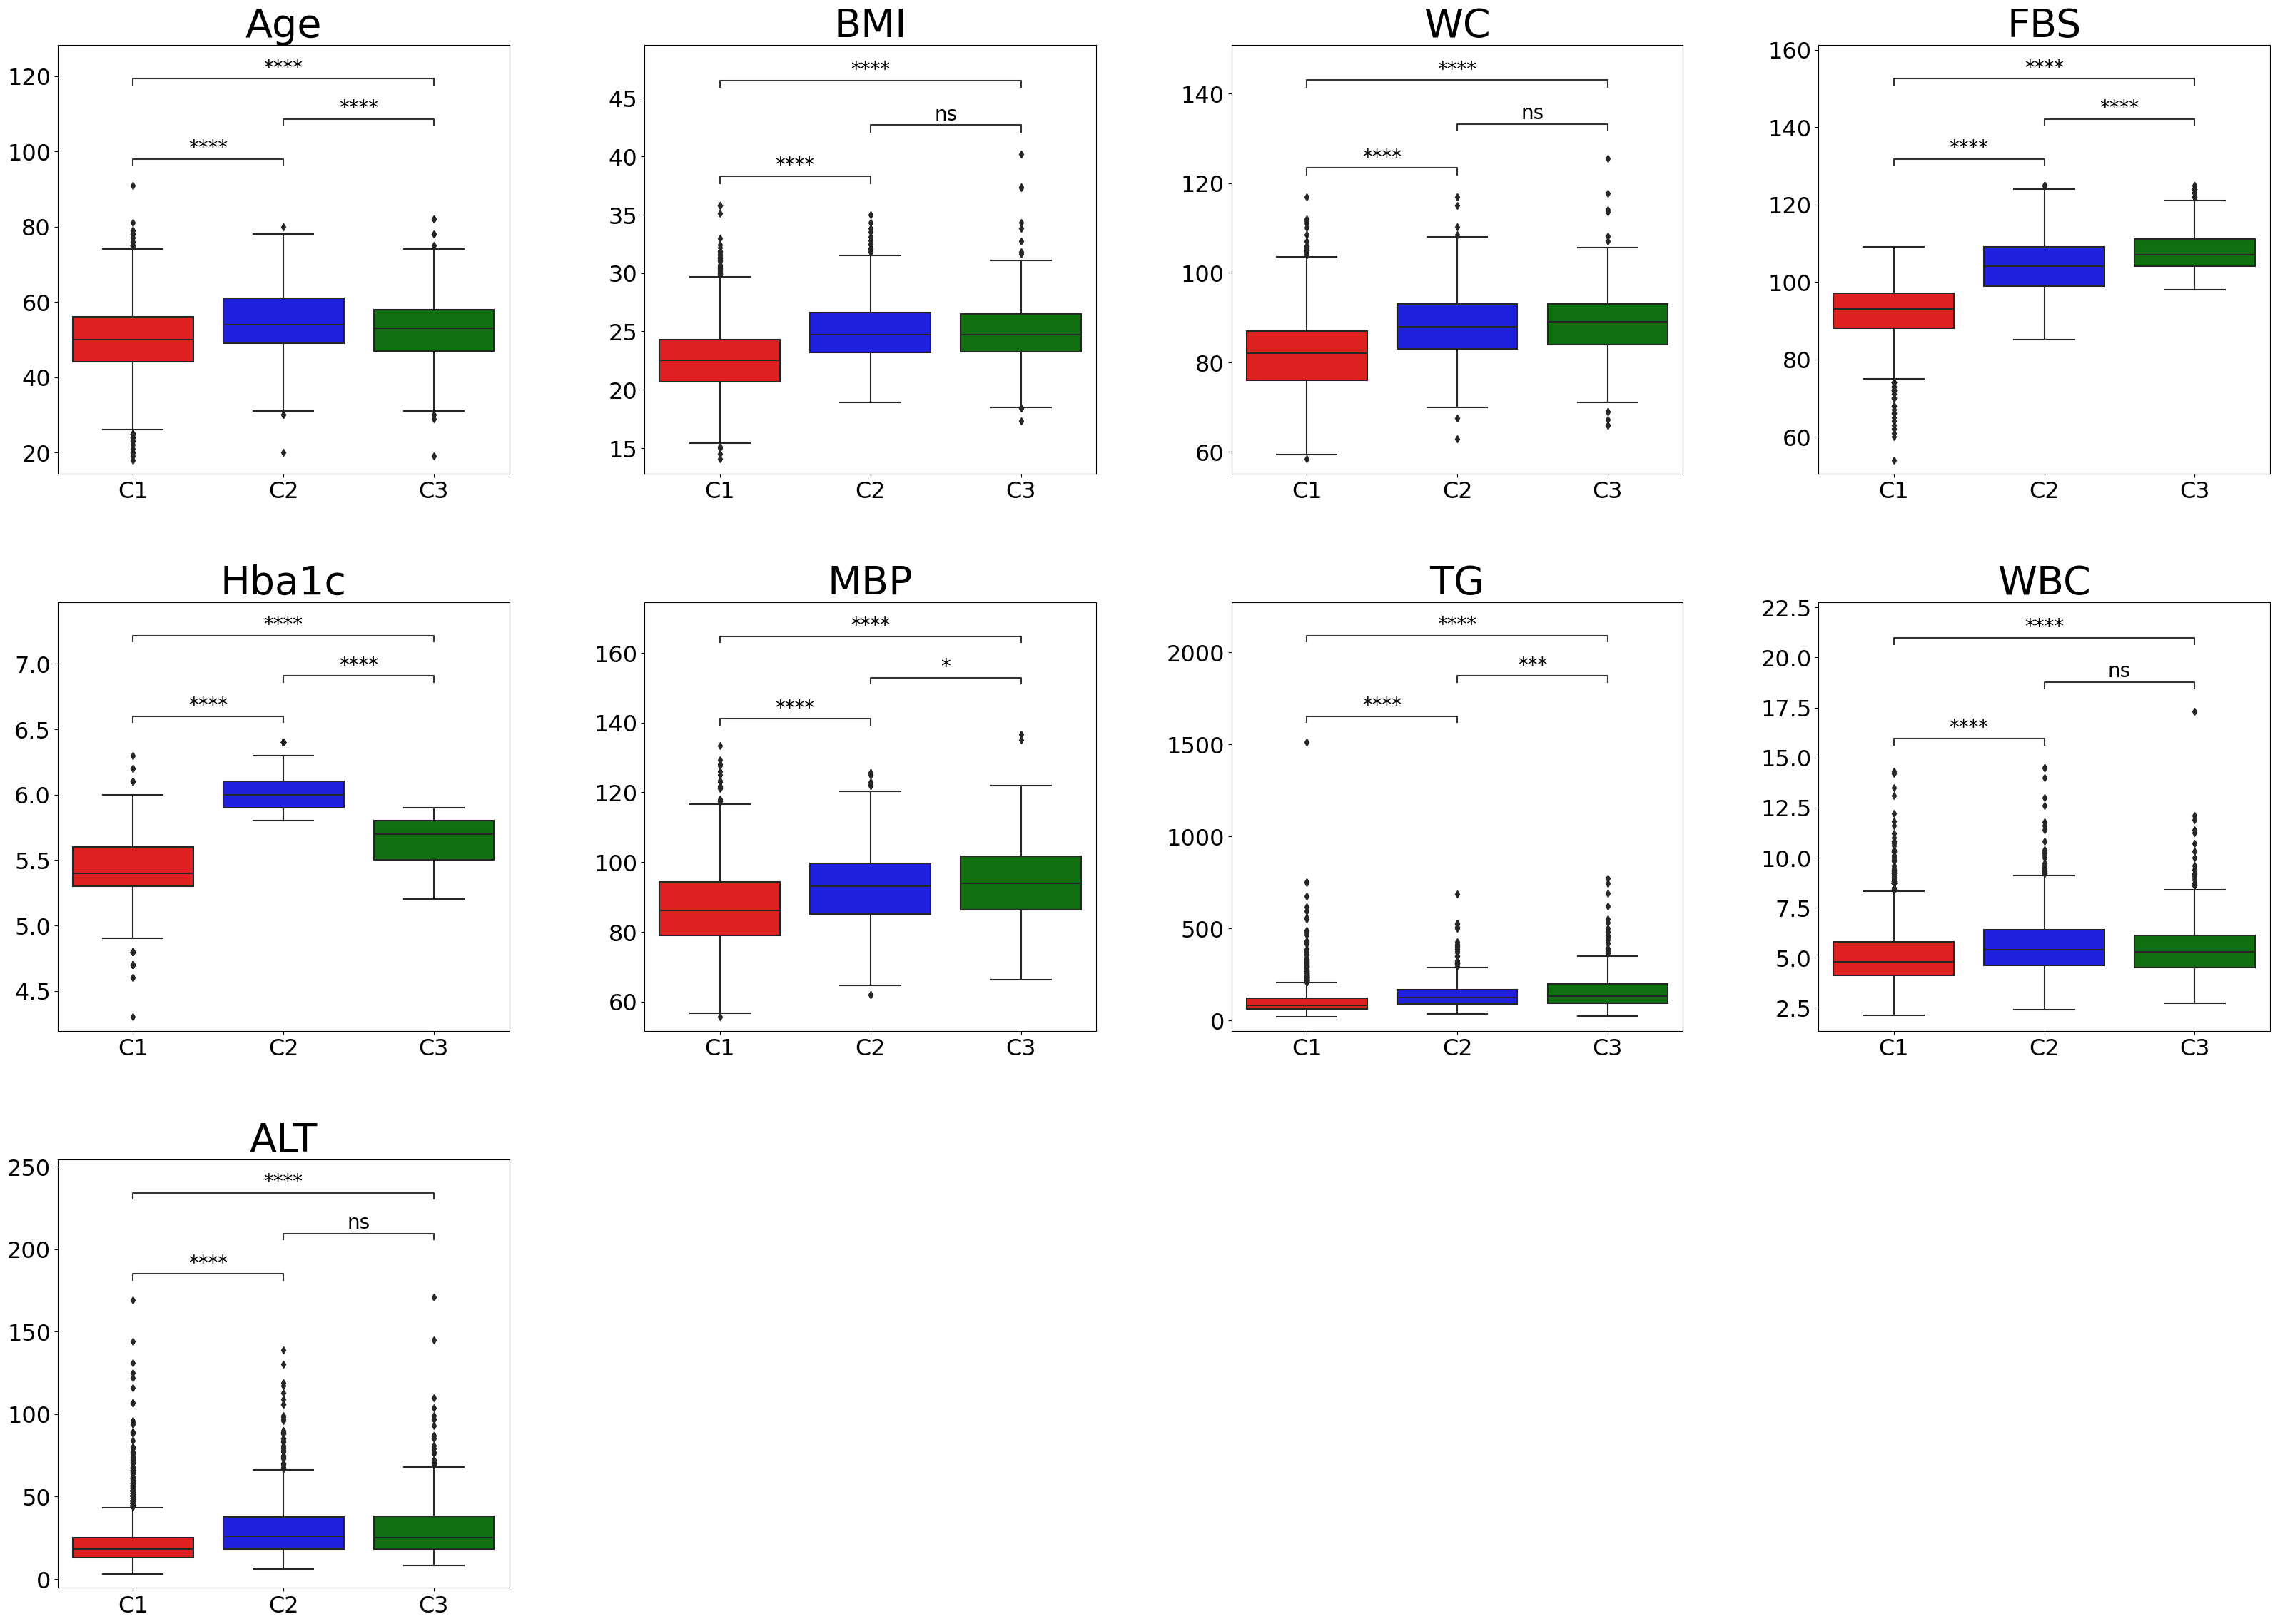

In [47]:
from statannotations.Annotator import Annotator

feature_name = {
    'age': 'Age', 'bmi': 'BMI', 'waist': 'WC', 'sys': 'SBP', 'dia': 'DBP', 'Tg': 'TG',
    'FINS': r'Insulin$^{+}$', 'HOMA-IR': 'HOMA-IR$^{+}$', 'HOMA-B': 'HOMA-beta$^{+}$'
}

fig = plt.figure(figsize=(40, 23))
ax1 = fig.add_subplot(111)

for i, FEATURE in enumerate(conti_feature_lst, start=1):
    x = 'Endotype'
    y = FEATURE

    plt.subplot(3, 4, i)
    ax = sns.boxplot(x=x, y=y, data=total_data, palette=color_map_dict)
    ax.set(xlabel=None, ylabel=None)

    # Annotation 글씨 크기 조정
    for text in ax.texts:
        text.set_fontsize(20)
        
    # Annotator 객체 사용
    annotator = Annotator(ax, P_combi, data=total_data, x=x, y=y)
    annotator.configure(
        test='t-test_ind',
        text_format='star',
        loc='inside',
        fontsize=20,
        comparisons_correction=None
    )
    annotator.apply_and_annotate()


    # title 설정
    title_name = feature_name.get(FEATURE, FEATURE)
    plt.title(title_name, fontsize=40)

    plt.rc('xtick', labelsize=23)
    plt.rc('ytick', labelsize=23)

plt.subplots_adjust(wspace=0.3, hspace=0.3, top=0.99, bottom=0.05)

# 전체 figure 설정
ax1.spines['top'].set_color('none')
ax1.spines['bottom'].set_color('none')
ax1.spines['left'].set_color('none')
ax1.spines['right'].set_color('none')
ax1.tick_params(labelcolor='w', top=False, bottom=False, left=False, right=False)

# 저장
# fig.savefig("./Clustering_분석결과/continuous_features_box_graph_total_0529.png",
#             dpi=300, bbox_inches='tight', transparent=True, format='png')
plt.show()

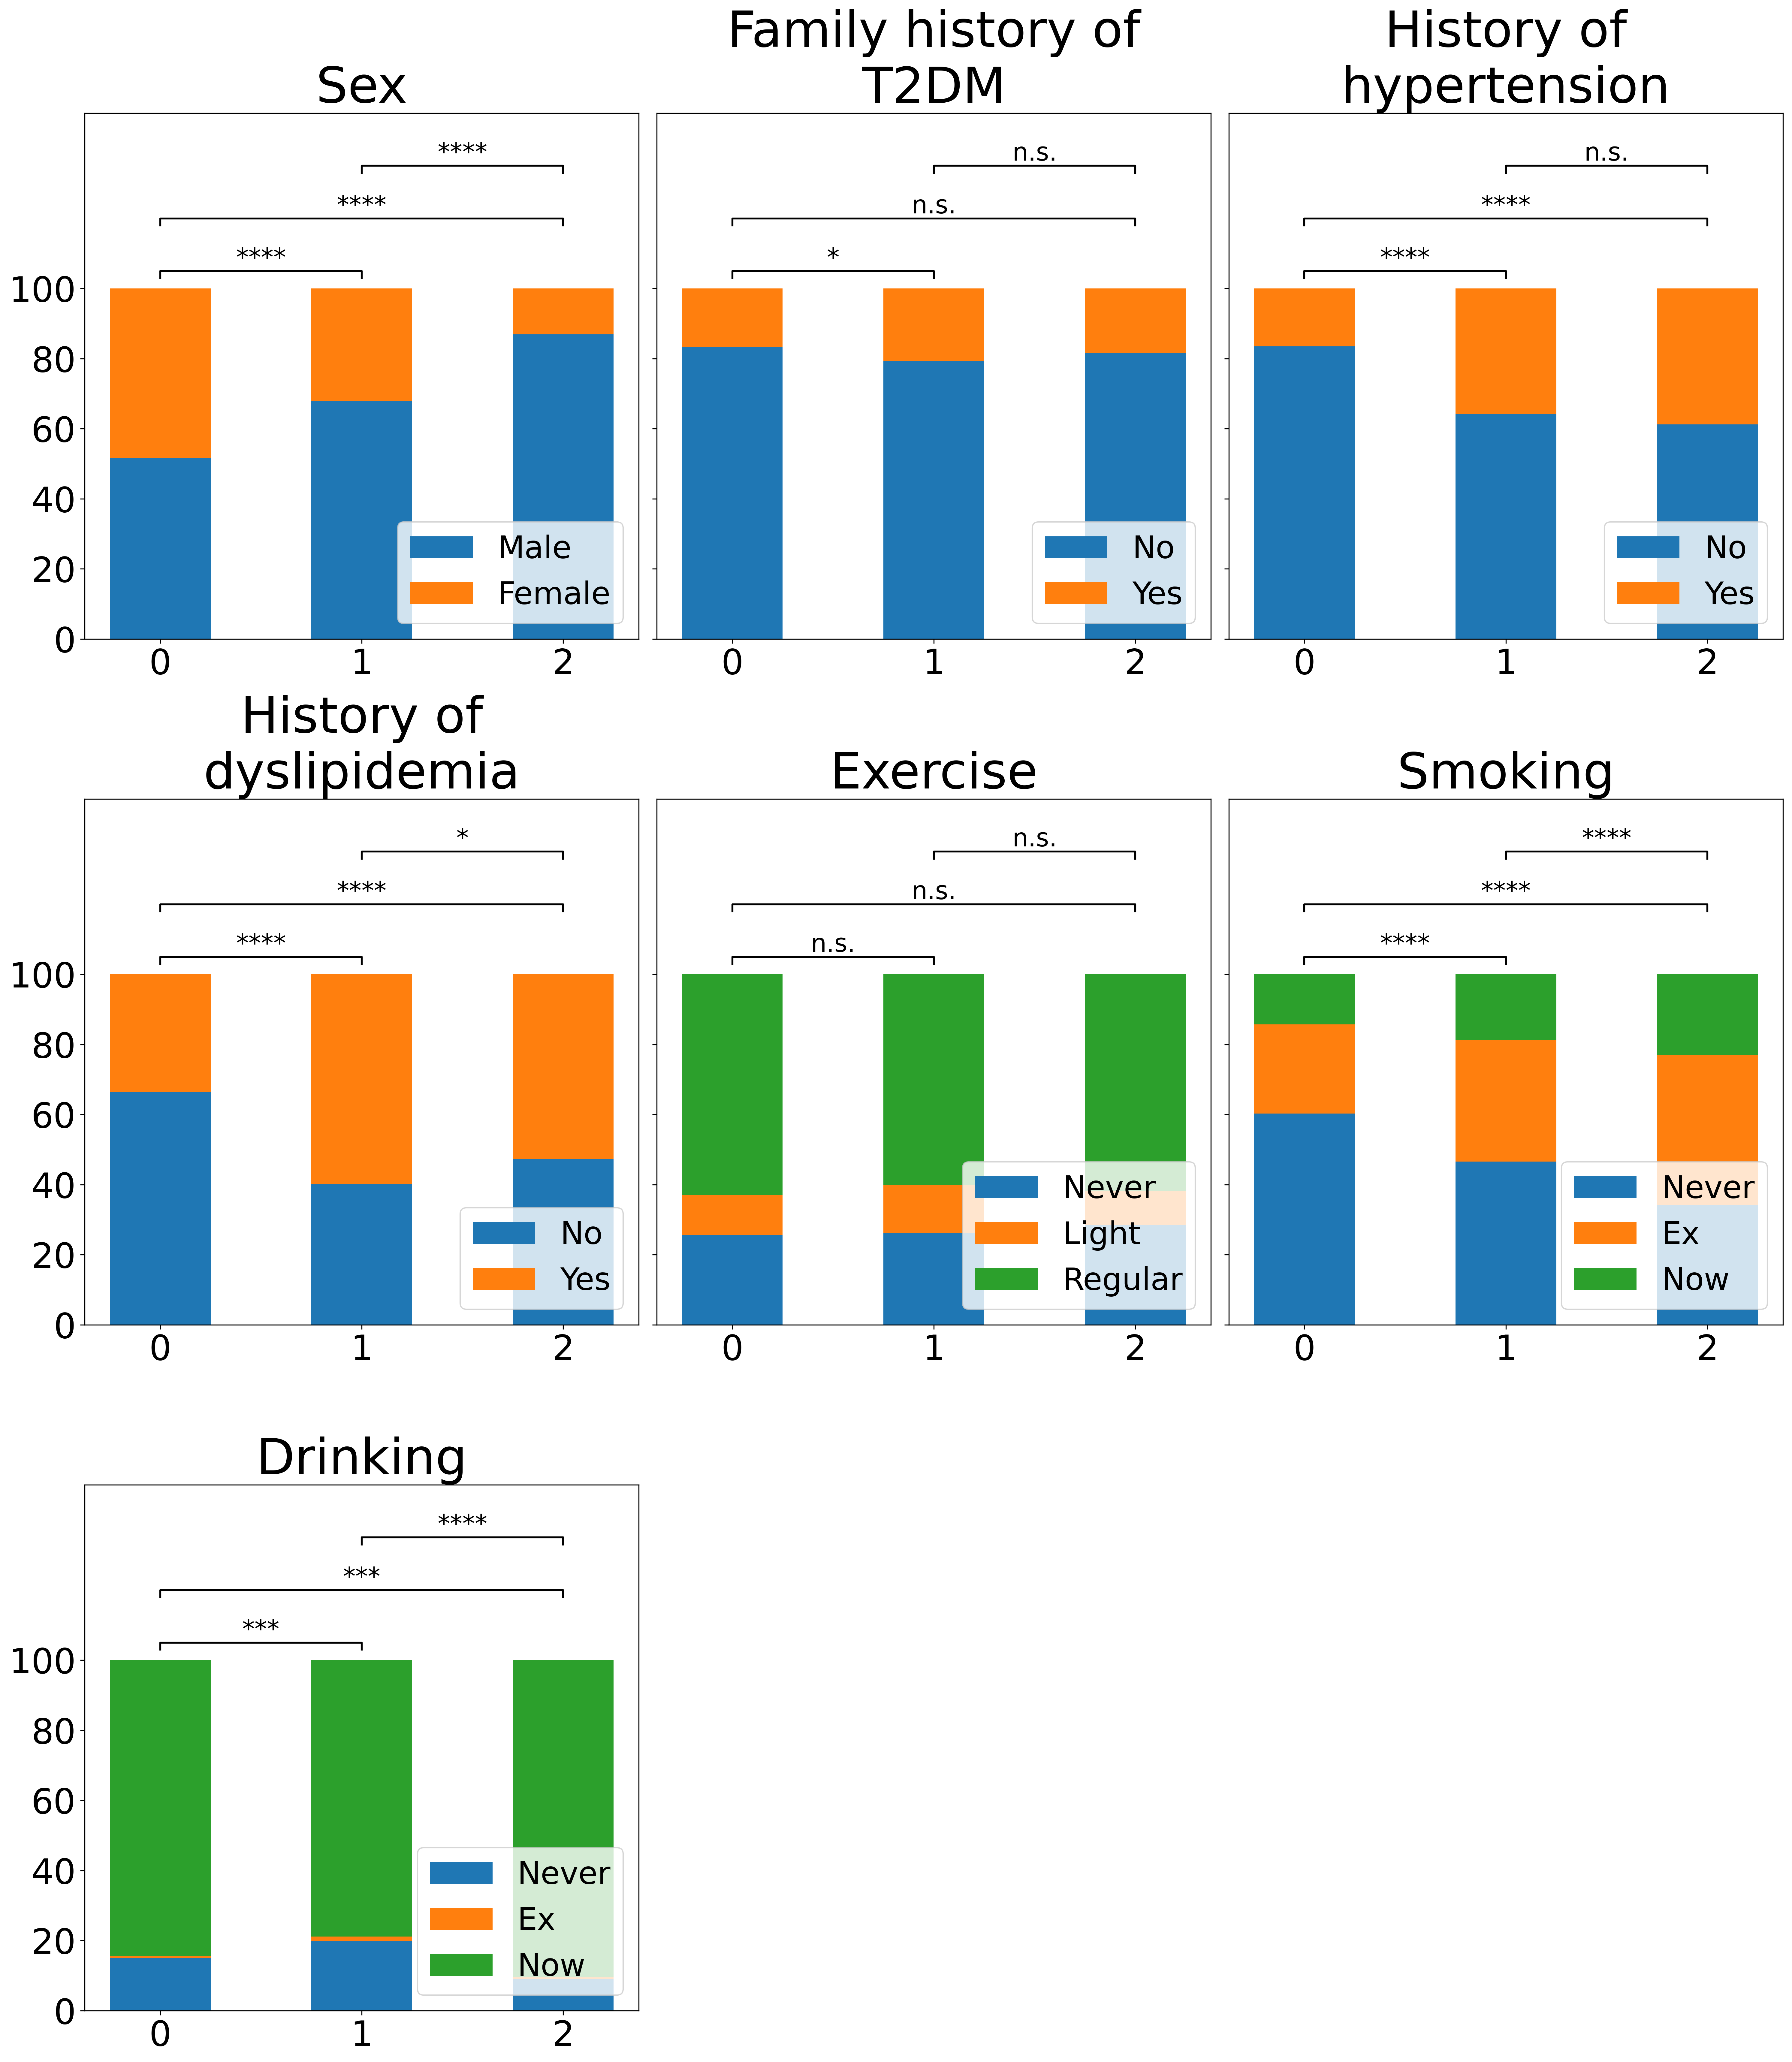

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import chi2_contingency

# --- 데이터 복사 ---
df = data.copy()
group_var = 'cluster'
categorical_vars = ['sex', 'DM_FH', 'htndiag', 'lipdiag', 'exercise', 'smoke', 'drink']
# categorical_vars = ['sex', 'DM_FH', 'htndiag', 'lipdiag']

# 범주 순서
category_orders = {
    'sex': ['Male', 'Female'],
    'DM_FH': ['No', 'Yes'],
    'exercise': ['Never', 'Light', 'Regular'],
    'smoke': ['Never', 'Ex', 'Now'],
    'drink': ['Never', 'Ex', 'Now'],
    'progress_DM': ['No', 'Yes'],
    'htndiag': ['No', 'Yes'],
    'lipdiag': ['No', 'Yes']
}

# 숫자 → 문자열 변환
df = df.replace({
    'sex': {1: 'Male', 2: 'Female'},
    'DM_FH': {0: 'No', 1: 'Yes'},
    'exercise': {0.: 'Never', 1.: 'Light', 2.: 'Regular'},
    'smoke': {0.: 'Never', 1.: 'Ex', 2.: 'Now'},
    'drink': {0: 'Never', 1: 'Ex', 2: 'Now'},
    'progress_DM': {0: 'No', 1: 'Yes'},
    'htndiag': {0: 'No', 1: 'Yes'},
    'lipdiag': {0: 'No', 1: 'Yes'}
})

title_lst = ['Sex', 'Family history of\nT2DM', 'History of\nhypertension', 'History of\ndyslipidemia',
             'Exercise', 'Smoking', 'Drinking']

# 별표 변환 함수
def get_pvalue_stars(p):
    if p > 0.05:
        return "n.s."
    elif p > 0.01:
        return "*"
    elif p > 0.001:
        return "**"
    elif p > 0.0001:
        return "***"
    else:
        return "****"

# 그래프 생성
n_vars = len(categorical_vars)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20), sharey=True, dpi=300)
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10), sharey=True, dpi=300)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 23), sharey=True, dpi=300)
axes = axes.flatten()

for i, cat_var in enumerate(categorical_vars):
    ax = axes[i]
    count_data = pd.crosstab(df[group_var], df[cat_var])

    # 카테고리 순서 적용
    if cat_var in category_orders:
        valid_categories = [cat for cat in category_orders[cat_var] if cat in count_data.columns]
        count_data = count_data[valid_categories]

    percent_data = count_data.div(count_data.sum(axis=1), axis=0) * 100
    bottoms = np.zeros(len(percent_data.index))
    bar_width = 0.5

    for category in percent_data.columns:
        heights = percent_data[category].values
        ax.bar(percent_data.index, heights, bottom=bottoms, label=category, width=bar_width)
        bottoms += heights

    ax.set_title(title_lst[i], fontsize=40)
    ax.set_ylim(0, 150)
    ax.tick_params(axis='y', labelsize=28)
    ax.tick_params(axis='x', labelsize=28)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.legend(loc='lower right', fontsize=25)

    # --- 카이제곱 검정 및 유의성 표시 ---
    groups = list(count_data.index)
    if len(groups) > 1:
        # 각 그룹쌍 조합에 대해 개별적으로 유의성 표시
        pairs = list(combinations(groups, 2))
        for j, (g1, g2) in enumerate(pairs):
            # 2xN contingency table 생성
            g1_vals = df[df[group_var] == g1][cat_var]
            g2_vals = df[df[group_var] == g2][cat_var]
            categories = np.union1d(g1_vals.unique(), g2_vals.unique())
            g1_counts = [np.count_nonzero(g1_vals == cat) for cat in categories]
            g2_counts = [np.count_nonzero(g2_vals == cat) for cat in categories]
            contingency = np.array([g1_counts, g2_counts])
            chi2, p, _, _ = chi2_contingency(contingency)
            stars = get_pvalue_stars(p)

            # 막대 위치 계산
            x1 = groups.index(g1)
            x2 = groups.index(g2)
            x1_center = x1  # x1 + x_offset 도 가능
            x2_center = x2
            x_center = (x1_center + x2_center) / 2
            height = bottoms.max() + 5 + j * 15  # 가장 높은 막대 위로 일정 간격

            ax.plot([x1_center, x1_center, x2_center, x2_center],
                [height - 2, height, height, height - 2],
                lw=1.5, color='black')

            ax.text(x_center, height, stars, ha='center', va='bottom', fontsize=20)


    else:
        ax.text(0.5, 0.5, "단일 그룹 - 검정 없음", ha='center', va='center', transform=ax.transAxes)

# 남은 subplot 숨기기
for i in range(n_vars, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
# plt.savefig("./Clustering_분석결과/categorical_features_box_graph_total_0529.png", dpi=300, bbox_inches='tight', transparent=True, format='png')
plt.show()

In [ ]:
# SNP data
#5493
SNP_data_AN_AS = pd.read_csv('/nfs-data-123/ehkang/Glucose/Data/SW1/gwas_snp/anas_snp_110.csv')
SNP_data_AN_AS.rename(columns = {'sample' : 'dist_id'}, inplace = True)
#66798
SNP_data_CT_NC = pd.read_csv('/nfs-data-123/ehkang/Glucose/Data/SW1/gwas_snp/dn_snp_110.csv')
SNP_data_CT_NC.rename(columns = {'sample' : 'dist_id'}, inplace = True)
#965
SNP_data_SNUH1 = pd.read_csv('/nfs-data-123/ehkang/Glucose/Data/SW1/gwas_snp/snuh_2349_snp_110.csv')
SNP_data_SNUH1.rename(columns = {'sample' : 'dist_id'}, inplace = True)
#4106
SNP_data_SNUH2 = pd.read_csv('/nfs-data-123/ehkang/Glucose/Data/SW1/gwas_snp/snuh_8000_snp_110.csv')
SNP_data_SNUH1.rename(columns = {'sample' : 'dist_id'}, inplace = True)

In [ ]:
# SNP data + cluster
ANAS_SNP_data = pd.merge(data[['dist_id','cluster']],SNP_data_AN_AS).reset_index(drop=True)
CTNC_SNP_data = pd.merge(data[['dist_id','cluster']],SNP_data_CT_NC).reset_index(drop=True)
SNP_data = pd.concat([ANAS_SNP_data,CTNC_SNP_data],axis=0).reset_index(drop=True)

In [ ]:
SNP_lst = [col for col in SNP_data.columns if col.startswith("rs")]

In [ ]:
# SciPy의 chi-square로 직접 계산한 p-value
chi2_results = []
for snp in SNP_lst:
    contingency_table = pd.crosstab(SNP_data['cluster'], SNP_data[snp])
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    chi2_results.append({"SNP": snp, "Chi-square": chi2_stat, "SciPy P-Value": p_value})

chi2_df = pd.DataFrame(chi2_results).set_index("SNP")
chi2_df

In [ ]:
# FDR 
import statsmodels.stats.multitest as smm

# SciPy P-Value 추출
p_values = chi2_df["SciPy P-Value"]
# Benjamini-Hochberg (BH) FDR 보정 적용
rejected, fdr_p_values = smm.fdrcorrection(p_values, alpha=0.05, method='indep')
# FDR 결과를 chi2_df에 추가
chi2_df["FDR Adjusted P-Value"] = fdr_p_values
chi2_df[chi2_df['FDR Adjusted P-Value']<0.001]

In [ ]:
SNP_lst = chi2_df[chi2_df['FDR Adjusted P-Value']<0.001].index.tolist()

In [ ]:
groupby='cluster'
#groupby='progress_DM'

mytable=tableone.TableOne(SNP_data,columns=SNP_lst,categorical=SNP_lst,groupby=groupby,pval=True)
pd.set_option('display.max_rows',None)
mytable